<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/Gradient_Descent_scaratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
from sklearn.datasets import make_regression
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [86]:
X,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=80,random_state=13)

In [114]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=13)

In [87]:
X

array([[-0.71239066],
       [-0.43714566],
       [-0.45375238],
       [ 0.95283061],
       [ 0.23785784],
       [ 0.86121137],
       [-0.24332625],
       [ 0.18494595],
       [-0.72099967],
       [-0.42989708],
       [ 2.01522083],
       [ 0.39724133],
       [ 0.20780005],
       [-0.23242587],
       [-0.76862702],
       [ 0.45315861],
       [ 0.63988397],
       [ 0.3595323 ],
       [-1.61510796],
       [ 1.74924179],
       [-0.78898902],
       [-0.51196509],
       [-0.92833523],
       [ 2.15038297],
       [-0.2073497 ],
       [-1.63909341],
       [-0.33861825],
       [-0.32212366],
       [-0.48137142],
       [-0.52316421],
       [ 0.72196506],
       [ 0.76591105],
       [ 0.45348104],
       [-1.26160595],
       [-2.18711527],
       [-1.18541881],
       [ 0.21745166],
       [ 1.33031692],
       [-1.08718159],
       [ 0.56226171],
       [-1.51284512],
       [-0.00238903],
       [-0.27813452],
       [ 0.45181234],
       [ 1.19070527],
       [ 0

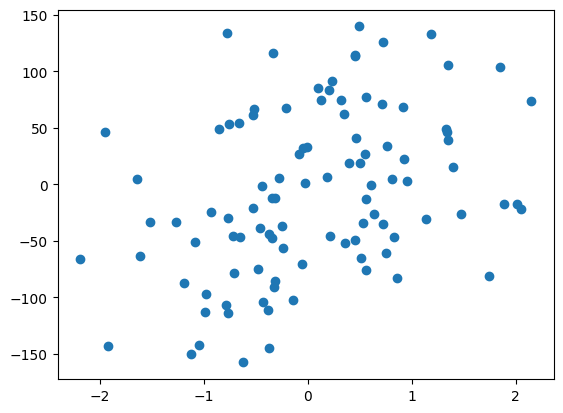

In [88]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [115]:
# lets apply ots
reg=LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [90]:
reg.coef_

array([28.48743864])

In [91]:
reg.intercept_

np.float64(-9.17897823470792)

In [116]:
# cross cal scrore
np.mean(cross_val_score(reg,X,y,scoring="r2",cv=10))

np.float64(0.055307395723161665)

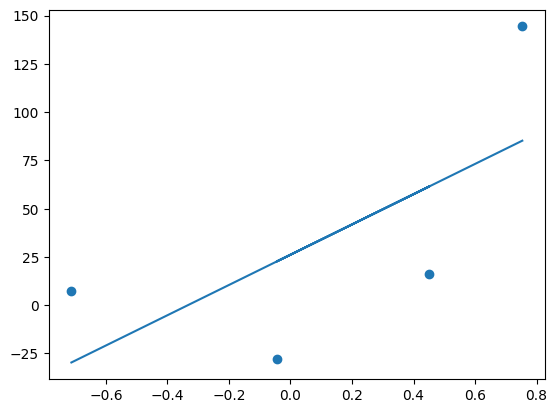

In [70]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X))

In [71]:
# let apply gradient descent
# and let assume the incetercept value of b=0 and assuming slope is constant m=78.35
y_pre=((78.35*X)+0).reshape(4)

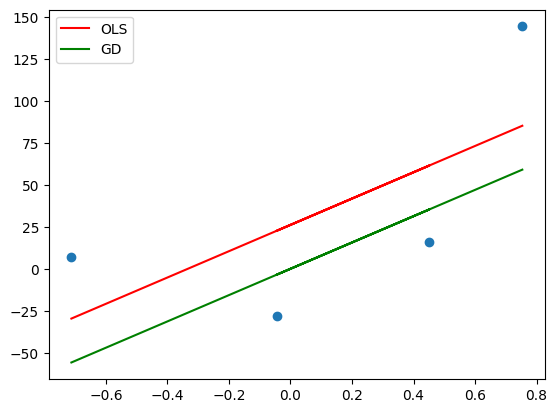

In [72]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color="Red",label="OLS")
plt.plot(X,y_pre,color="Green",label="GD")
plt.legend()
#

In [73]:
m=78.35
b=0
loss_slope=-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-209.27763408209216)

In [74]:
# let make learning slope
lr=0.1
step_size=lr*loss_slope
step_size


np.float64(-20.927763408209216)

In [75]:
# calculating new intercept
b=b-step_size
b

np.float64(20.927763408209216)

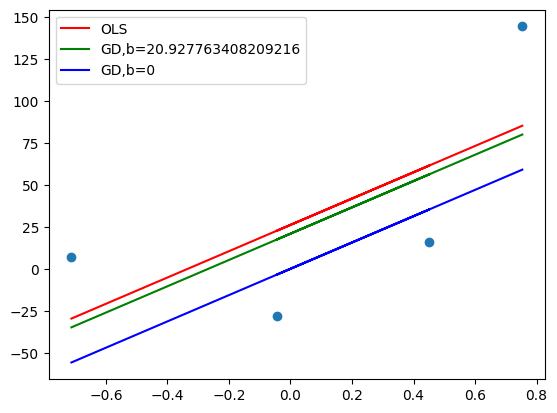

In [30]:
y_pre1=((78.35*X)+b).reshape(4)
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color="Red",label="OLS")
plt.plot(X,y_pre1,color="Green",label=f'GD,b={b}')
plt.plot(X,y_pre,color="Blue",label="GD,b=0")
plt.legend()

In [31]:
# iteration 2
loss_slope=-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-41.85552681641843)

In [32]:
lr=0.1
step_size=lr*loss_slope
step_size

np.float64(-4.185552681641844)

In [33]:
# calculating new intercept
b=b-step_size
b

np.float64(25.11331608985106)

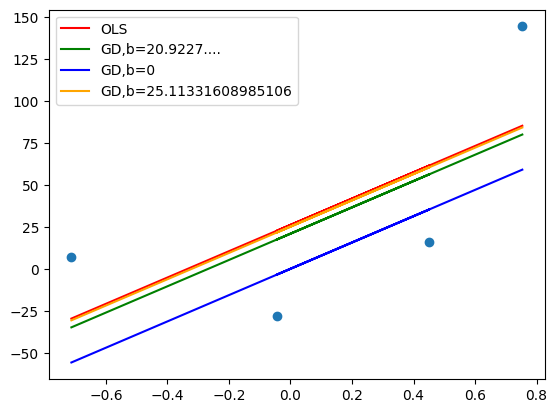

In [35]:
y_pre2=((78.35*X)+b).reshape(4)
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color="Red",label="OLS")
plt.plot(X,y_pre1,color="Green",label=f'GD,b=20.9227....')
plt.plot(X,y_pre,color="Blue",label="GD,b=0")
plt.plot(X,y_pre2,color="Orange",label=f'GD,b={b}')
plt.legend()

In [45]:
# interation 3
loss_slope=-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(2.3439095017194234)

In [44]:
lr=0.1
step_size=lr*loss_slope
step_size

np.float64(-0.16742210726567353)

In [46]:
# calculating new intercept
b=b-step_size
b

np.float64(26.62011505524212)

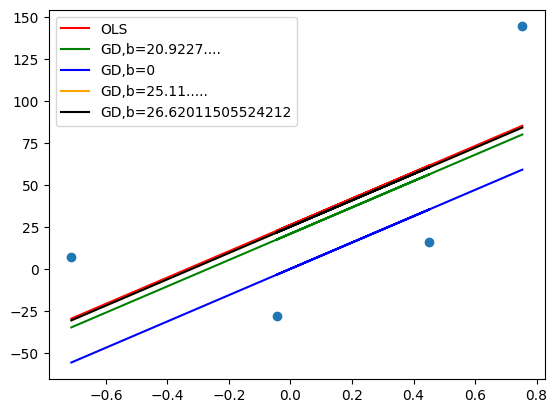

In [47]:
y_pre3=((78.35*X)+b).reshape(4)
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color="Red",label="OLS")
plt.plot(X,y_pre1,color="Green",label=f'GD,b=20.9227....')
plt.plot(X,y_pre,color="Blue",label="GD,b=0")
plt.plot(X,y_pre2,color="Orange",label=f'GD,b=25.11.....')
plt.plot(X,y_pre2,color="Black",label=f'GD,b={b}')
plt.legend()

# **Creating my own class for this **

In [109]:
class GRDScaratch:
  def __init__(self,learing_rate,epoches):
    self.lr=learing_rate
    self.epoches=epoches
    self.m=100
    self.b=-120

  def fit(self,X,y):
    # calulate b using
    for i in range(self.epoches):
      loss_slope_wrtb_=-2*np.sum(y-self.m*X.ravel()-self.b)
      loss_slope_wrtm_=-2*np.sum((y-self.m*X.ravel()-self.b)*X.ravel())
      self.b=self.b-self.lr*loss_slope_wrtb_
      self.m=self.m-self.lr*loss_slope_wrtm_
    print(f"coefficent is {self.b} and slope is{self.m}" )
  def predict(self,X):
    return self.m*X+self.b

In [118]:
X,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=80,random_state=13)
gd=GRDScaratch(learing_rate=0.01,epoches=10)
gd.fit(X_train,y_train)

coefficent is -9.420772652020988 and slope is32.16315093004398


In [121]:
y_pred=gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)


0.018796540692650576